# Job Satisfaction Prediction Pipeline
End-to-end ML pipeline: data cleaning → feature engineering → model training & evaluation.

## Imports

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, VotingRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

NULLS_THRESHOLD = 0.5
CARDINALITY_THRESHOLD = 15
CORRELATION_THRESHOLD = 0.9
VARIANCE_THRESHOLD = 0.01
MI_THRESHOLD = 0.01 # Not used now


    ## Load Data

In [24]:
data = pd.read_csv("train_data.csv")
print("Original shape:", data.shape)

Original shape: (44191, 156)


##  Drop Rows with Missing Target
Remove rows where `JobSat` (the target) is missing — we can't train on unlabelled rows.

In [25]:
data = data.dropna(subset=["JobSat"])
print("After dropping missing JobSat:", data.shape)

After dropping missing JobSat: (23961, 156)


## Separate Target & Drop Missing Target Rows 


In [26]:
# Separate target
y = data["JobSat"]
data = data.drop(columns=["JobSat", "ResponseId"])

# Drop columns with >NULLS_THRESHOLD% missing values
threshold = NULLS_THRESHOLD * len(data)
cols_to_drop = data.columns[data.isnull().sum() > threshold]
data = data.drop(columns=cols_to_drop)

print(f"Shape after initial cleaning: {data.shape}")
print(f"Duplicates: {data.duplicated().sum()}")


Shape after initial cleaning: (23961, 108)
Duplicates: 0


## Plot — Missing Values per Column

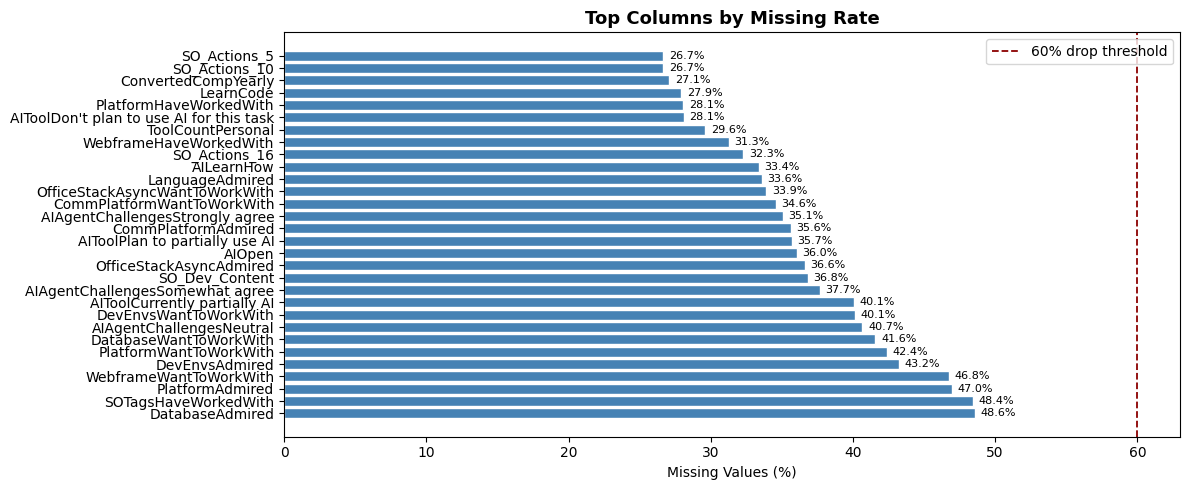

In [27]:
missing_pct = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0].head(30)

if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['tomato' if v > 60 else 'steelblue' for v in missing_pct.values]
    bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white')
    ax.axvline(60, color='darkred', linestyle='--', linewidth=1.3, label='60% drop threshold')
    ax.set_xlabel('Missing Values (%)')
    ax.set_title('Top Columns by Missing Rate', fontweight='bold', fontsize=13)
    ax.legend()
    for bar, v in zip(bars, missing_pct.values):
        ax.text(v + 0.4, bar.get_y() + bar.get_height() / 2,
                f'{v:.1f}%', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')


## Plot — Target Variable Distribution

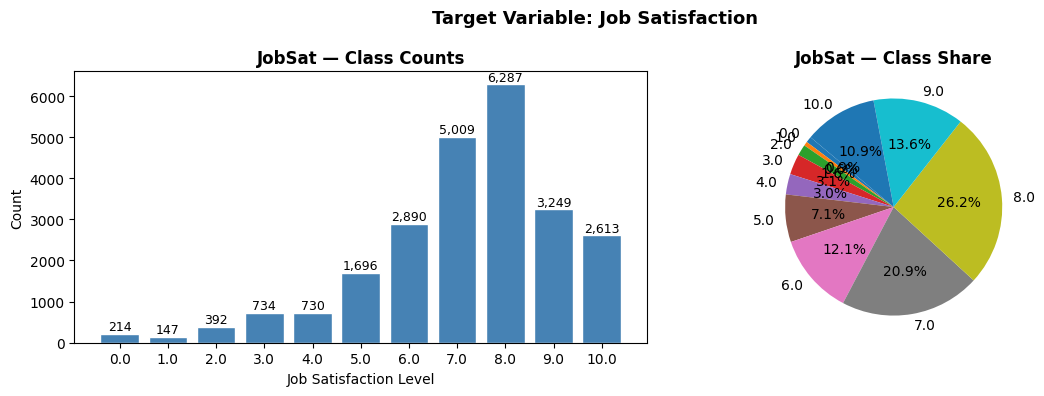

In [28]:
vc = y.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
axes[0].set_title('JobSat — Class Counts', fontweight='bold')
axes[0].set_xlabel('Job Satisfaction Level')
axes[0].set_ylabel('Count')
for patch, v in zip(axes[0].patches, vc.values):
    axes[0].text(patch.get_x() + patch.get_width() / 2,
                 patch.get_height() + 15,
                 f'{v:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(vc.values, labels=vc.index.astype(str), autopct='%1.1f%%',
            startangle=140, colors=list(plt.cm.tab10.colors[:len(vc)]))
axes[1].set_title('JobSat — Class Share', fontweight='bold')

plt.suptitle('Target Variable: Job Satisfaction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Train / Test Split (FIX: done immediately after cleaning)
Splitting here prevents data leakage — all subsequent preprocessing steps
will be fit on `X_train` only and applied separately to `X_test`.

In [29]:
# FIX 1: Split immediately after cleaning
X_train, X_test, y_train, y_test = train_test_split(
    data, y,
    test_size=0.2,
    random_state=42,
    stratify=None  # y is continuous; use stratify=y if ordinal classes
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (19168, 108), Test size: (4793, 108)


## Split Column Types

In [30]:
numerical_cols   = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical cols  : {len(numerical_cols)}")
print(f"Categorical cols: {len(categorical_cols)}")


Numerical cols  : 36
Categorical cols: 72


## Plot — Numerical Column Distributions

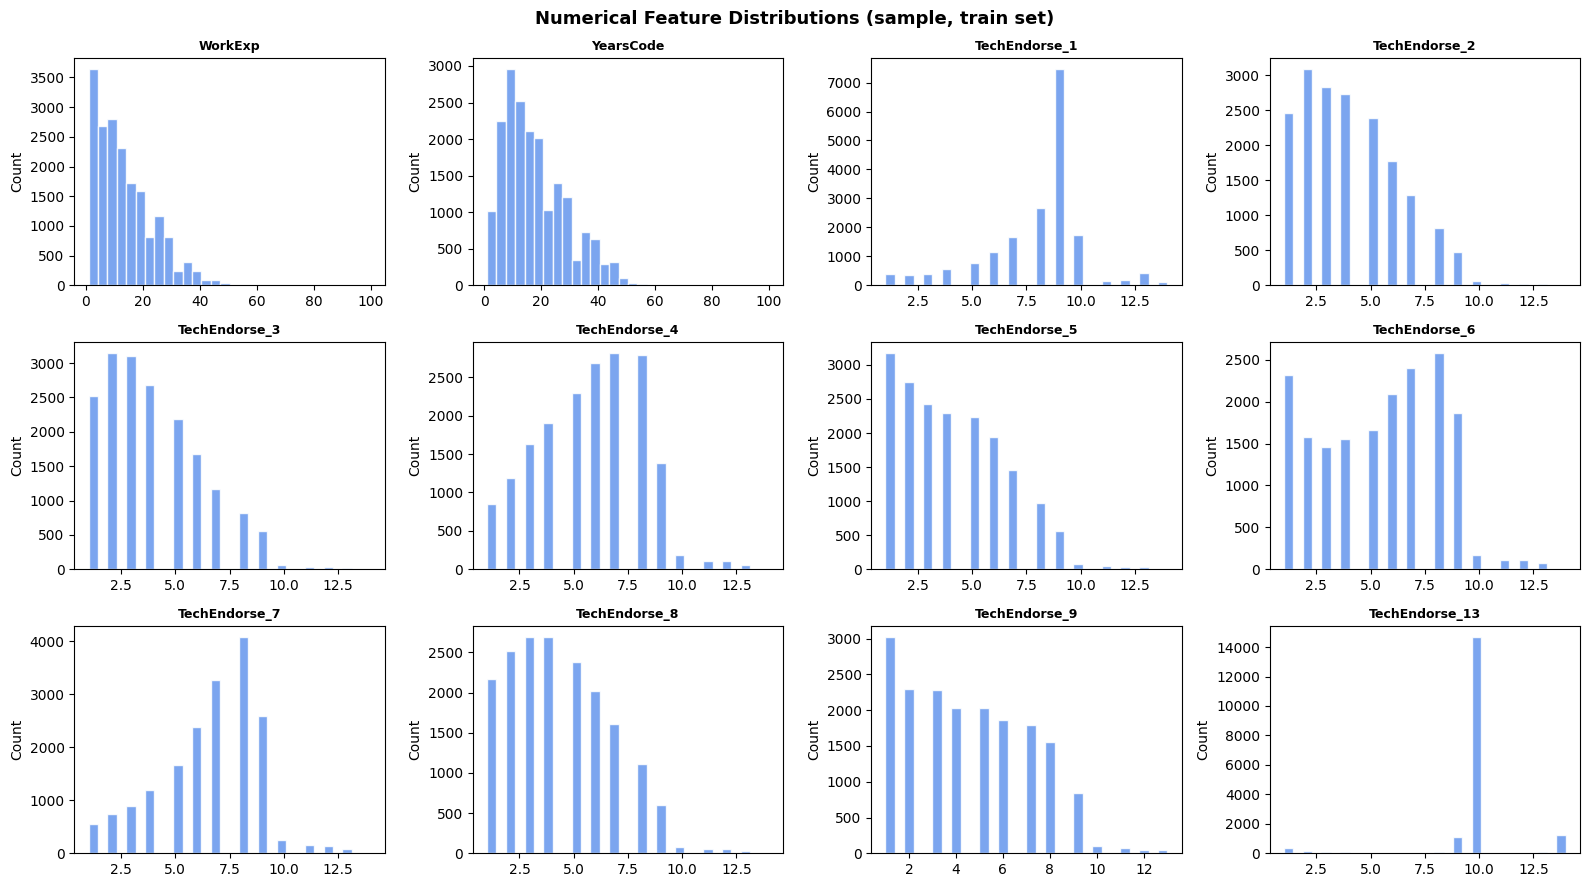

In [31]:
sample_cols = numerical_cols[:12]
ncols = 4
nrows = -(-len(sample_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for ax, col in zip(axes, sample_cols):
    ax.hist(X_train[col].dropna(), bins=30, color='cornflowerblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Count')

for ax in axes[len(sample_cols):]:
    ax.set_visible(False)

plt.suptitle('Numerical Feature Distributions (sample, train set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Impute Numerical Columns (FIX: fit on X_train only)

In [32]:
print("Starting Safe RF Imputation...")

# FIX 2: replace/clip on each split separately
X_train[numerical_cols] = X_train[numerical_cols].replace([np.inf, -np.inf], np.nan)
X_train[numerical_cols] = X_train[numerical_cols].clip(lower=-1e12, upper=1e12)
X_test[numerical_cols]  = X_test[numerical_cols].replace([np.inf, -np.inf], np.nan)
X_test[numerical_cols]  = X_test[numerical_cols].clip(lower=-1e12, upper=1e12)

rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=10, max_depth=10, n_jobs=-1, random_state=42
    ),
    max_iter=5,
    random_state=42
)

# FIX 2: fit on train only, transform both
X_train[numerical_cols] = rf_imputer.fit_transform(X_train[numerical_cols].astype(np.float64))
X_test[numerical_cols]  = rf_imputer.transform(X_test[numerical_cols].astype(np.float64))

print("Imputation completed.")


Starting Safe RF Imputation...
Imputation completed.


## Impute Categorical Columns (fill with "Unknown")

In [33]:
X_train[categorical_cols] = X_train[categorical_cols].fillna("Unknown")
X_test[categorical_cols]  = X_test[categorical_cols].fillna("Unknown")


## Outlier Capping (FIX: IQR bounds from X_train only)

In [34]:
numeric_cols = [
    col for col in X_train.select_dtypes(include=['int64', 'float64']).columns
    if X_train[col].nunique() > 20
]

# FIX 3: compute bounds from train only, apply same bounds to test
def compute_iqr_bounds(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

iqr_bounds = {}
for col in numeric_cols:
    lower, upper = compute_iqr_bounds(X_train, col)
    iqr_bounds[col] = (lower, upper)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print("Outlier capping done.")


Outlier capping done.


## Log-Transform Skewed Numerical Columns (FIX: skewness from X_train only)

In [35]:
# Store which columns were log transformed
skewed_cols = []

# FIX 3: skewness check on TRAIN only
for col in numeric_cols:
    if abs(X_train[col].skew()) > 1:
        skewed_cols.append(col)
        X_train[col] = np.log1p(X_train[col])
        X_test[col]  = np.log1p(X_test[col])
        print(f"  Log-transformed: {col}")

print("Log transform done.")


  Log-transformed: CompTotal
  Log-transformed: SO_Actions_15
Log transform done.


## Plot — Skewness After Capping & Log Transform

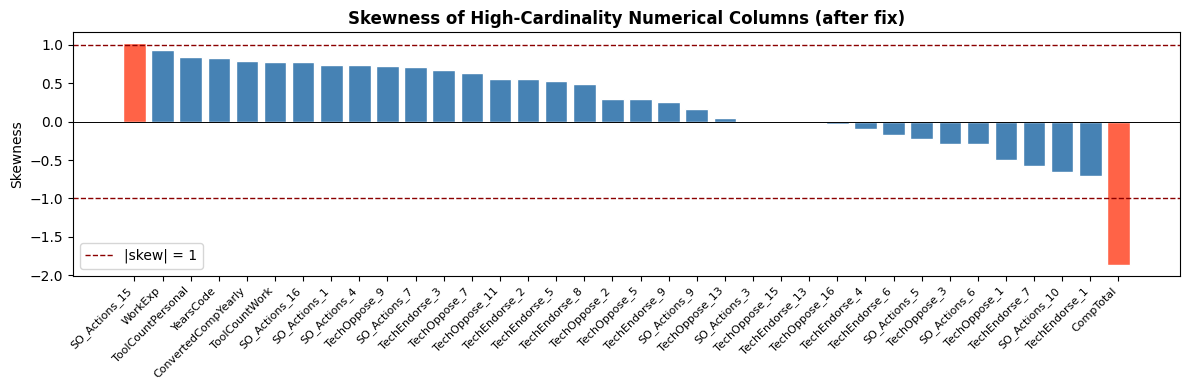

In [36]:
skew_vals = X_train[numeric_cols].skew().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = ['tomato' if abs(v) > 1 else 'steelblue' for v in skew_vals.values]
ax.bar(range(len(skew_vals)), skew_vals.values, color=bar_colors, edgecolor='white')
ax.axhline( 1, color='darkred', linestyle='--', linewidth=1, label='|skew| = 1')
ax.axhline(-1, color='darkred', linestyle='--', linewidth=1)
ax.axhline( 0, color='black', linewidth=0.7)
ax.set_xticks(range(len(skew_vals)))
ax.set_xticklabels(skew_vals.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Skewness')
ax.set_title('Skewness of High-Cardinality Numerical Columns (after fix)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## TF-IDF ENCODING (AIOpen, AIHuman)

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf_cols = ['AIOpen', 'AIHuman']

# tfidf_encoders = {}

# for col in tfidf_cols:
#     if col in X_train.columns:

#         # Fill nulls
#         train_text = X_train[col].fillna('')
#         test_text  = X_test[col].fillna('')

#         # Fit on train only
#         tfidf = TfidfVectorizer(max_features=50, stop_words='english')
#         tfidf.fit(train_text)

#         # Transform both
#         train_encoded = tfidf.transform(train_text).toarray()
#         test_encoded  = tfidf.transform(test_text).toarray()

#         # Create feature names
#         feat_names = [f"tfidf_{col}_{w}" for w in tfidf.get_feature_names_out()]

#         # Add to dataframes and drop original column
#         X_train = pd.concat([
#             X_train.drop(columns=[col]),
#             pd.DataFrame(train_encoded, columns=feat_names, index=X_train.index)
#         ], axis=1)

#         X_test = pd.concat([
#             X_test.drop(columns=[col]),
#             pd.DataFrame(test_encoded, columns=feat_names, index=X_test.index)
#         ], axis=1)

#         # Save encoder for test script
#         tfidf_encoders[col] = tfidf

#         print(f"TF-IDF applied to '{col}' → {len(feat_names)} features")

# print(f"Shape after TF-IDF: {X_train.shape}")

## Encode Binary Categorical Columns (FIX: applied to each split)

In [37]:
binary_map  = {"Yes": 1, "No": 0, "True": 1, "False": 0}
binary_cols = []

for col in X_train.select_dtypes(include="object").columns:
    unique_vals = set(X_train[col].dropna().unique())
    if unique_vals.issubset(set(binary_map.keys())):
        binary_cols.append(col)
        X_train[col] = X_train[col].map(binary_map).fillna(0) #we treat unknowns as no
        X_test[col]  = X_test[col].map(binary_map).fillna(0)

print(f"Binary-encoded {len(binary_cols)} columns: {binary_cols}")

Binary-encoded 0 columns: []


## Encode Multi-Value Columns (FIX: MLB fit on X_train only)

In [38]:
def encode_multi_value_columns(train_df, test_df, top_k=None):
    train_df  = train_df.copy()
    test_df   = test_df.copy()
    mlb_dict  = {}

    multi_cols = [
        col for col in train_df.select_dtypes(include="object").columns
        if train_df[col].str.contains(";", na=False).any()
    ]
    print("Multi-value columns:", multi_cols)

    for col in multi_cols:
        print(f"Processing {col}...")

        train_df[col] = train_df[col].fillna("").apply(lambda x: x.split(";") if x != "" else [])
        test_df[col]  = test_df[col].fillna("").apply(lambda x: x.split(";") if x != "" else [])

        if top_k:
            all_values = pd.Series([item for sublist in train_df[col] for item in sublist])
            top_values = set(all_values.value_counts().head(top_k).index)

            train_df[col] = train_df[col].apply(lambda x: [i if i in top_values else "UNKNOWN" for i in x])
            test_df[col]  = test_df[col].apply(lambda x: [i if i in top_values else "UNKNOWN" for i in x])

        train_df[col] = train_df[col].apply(lambda x: x if "UNKNOWN" in x else x + ["UNKNOWN"])

        mlb = MultiLabelBinarizer()
        train_encoded = mlb.fit_transform(train_df[col])
        test_encoded  = mlb.transform(test_df[col])
        cols = [f"{col}_{val}" for val in mlb.classes_]

        train_df = pd.concat([train_df, pd.DataFrame(train_encoded, columns=cols, index=train_df.index).astype(int)], axis=1).drop(columns=[col])
        test_df  = pd.concat([test_df,  pd.DataFrame(test_encoded,  columns=cols, index=test_df.index).astype(int)],  axis=1).drop(columns=[col])

        mlb_dict[col] = mlb

    return train_df, test_df, mlb_dict, multi_cols


X_train, X_test, mlb_dict, multi_cols = encode_multi_value_columns(X_train, X_test, top_k=15)
print("Multi-value encoding done. Shapes:", X_train.shape, X_test.shape)

Multi-value columns: ['EmploymentAddl', 'LearnCode', 'AILearnHow', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'DevEnvsHaveWorkedWith', 'DevEnvsWantToWorkWith', 'DevEnvsAdmired', 'SOTagsHaveWorkedWith', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'OfficeStackAsyncAdmired', 'CommPlatformHaveWorkedWith', 'CommPlatformWantToWorkWith', 'CommPlatformAdmired', 'SO_Dev_Content', 'AIToolCurrently partially AI', "AIToolDon't plan to use AI for this task", 'AIToolPlan to partially use AI', 'AIFrustration', 'AIExplain', 'AIAgentChallengesNeutral', 'AIAgentChallengesStrongly agree', 'AIAgentChallengesSomewhat agree', 'AIHuman', 'AIOpen']
Processing EmploymentAddl...
Processing LearnCode...
Processing AILearnHow.

## Encode Remaining Categorical Columns
- **Low cardinality (≤15 unique values):** One-hot encoding (fitted on X_train, reindexed on X_test)
- **High cardinality (>15 unique values):** Frequency encoding (frequencies computed from X_train only)

In [39]:
remaining_cat  = X_train.select_dtypes(include='object').columns
low_card_cols  = [col for col in remaining_cat if X_train[col].nunique() <= CARDINALITY_THRESHOLD]
high_card_cols = [col for col in remaining_cat if X_train[col].nunique() > CARDINALITY_THRESHOLD]

# Low cardinality → One-hot encoding
X_train = pd.get_dummies(X_train, columns=low_card_cols, drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=low_card_cols, drop_first=True, dtype=int)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
print(f"One-hot encoded {len(low_card_cols)} low-cardinality columns.")

# High cardinality → Frequency encoding (map from train)
freq_maps = {}
for col in high_card_cols:
    freq = X_train[col].value_counts(normalize=True)
    freq_maps[col] = freq
    X_train[col] = X_train[col].map(freq)
    X_test[col]  = X_test[col].map(freq).fillna(0)
print(f"Frequency encoded {len(high_card_cols)} high-cardinality columns.")

# Sanitize column names (fixes LightGBM / special-char issues)
def clean_col_names(df):
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X_train = clean_col_names(X_train)
X_test  = clean_col_names(X_test)
ohe_columns_sanitized = list(X_train.columns)
print("Encoding complete. Shape:", X_train.shape)


One-hot encoded 31 low-cardinality columns.
Frequency encoded 4 high-cardinality columns.
Encoding complete. Shape: (19168, 731)


## Feature Selection (FIX: all steps computed from X_train only)
Four-stage funnel: correlation filter → variance threshold → mutual information → RF importance.

In [40]:
X = X_train.copy()

# Step 1: Remove highly correlated features (>0.9)
corr_matrix  = X.corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORRELATION_THRESHOLD)]
X       = X.drop(columns=to_drop_corr)
X_test  = X_test.drop(columns=[c for c in to_drop_corr if c in X_test.columns])
print(f"After correlation filter: {X.shape}")

# Step 2: Remove low-variance features
X_before_variance = X.copy()
selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
X = pd.DataFrame(
    selector.fit_transform(X_before_variance),
    columns=X_before_variance.columns[selector.get_support()],
    index=X_before_variance.index
)
X_test = pd.DataFrame(
    selector.transform(X_test.reindex(columns=X_before_variance.columns, fill_value=0)),
    columns=X.columns,
    index=X_test.index
)
print(f"After variance filter: {X.shape}")

# Step 3: Mutual information filter (regression — continuous target)
# from sklearn.feature_selection import mutual_info_regression
# mi        = mutual_info_regression(X, y_train, random_state=42)
# mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
# selected  = mi_series[mi_series > MI_THRESHOLD].index
# X         = X[selected]
# X_test    = X_test[selected]
# print(f"After MI filter: {X.shape}")

# Step 4: Model-based selection (top 100 RF importances)
rf_fs = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_fs.fit(X, y_train)
importances  = pd.Series(rf_fs.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 features:\n", importances.head(10))
top_features = importances.head(100).index
X       = X[top_features]
X_test  = X_test[top_features]
print(f"After model-based selection: {X.shape}")

# Final safety clip
X      = X.clip(-1e6, 1e6).astype(np.float64)
X_test = X_test.clip(-1e6, 1e6).astype(np.float64)

X_train = X


After correlation filter: (19168, 666)
After variance filter: (19168, 585)

Top 10 features:
 NewRole_I_have_strongly_considered_changing_my_career_and_or_the_industry_I_work_in             0.074016
NewRole_I_have_somewhat_considered_changing_my_career_and_or_the_industry_I_work_in             0.044809
ConvertedCompYearly                                                                             0.025229
CompTotal                                                                                       0.020514
Employment_Not_employed                                                                         0.019595
WorkExp                                                                                         0.016179
PurchaseInfluence_Yes__I_influenced_the_purchase_of_a_substantial_addition_to_the_tech_stack    0.013990
ToolCountWork                                                                                   0.013740
ToolCountPersonal                                                 

## Plot — Feature Selection Funnel & Top Importances

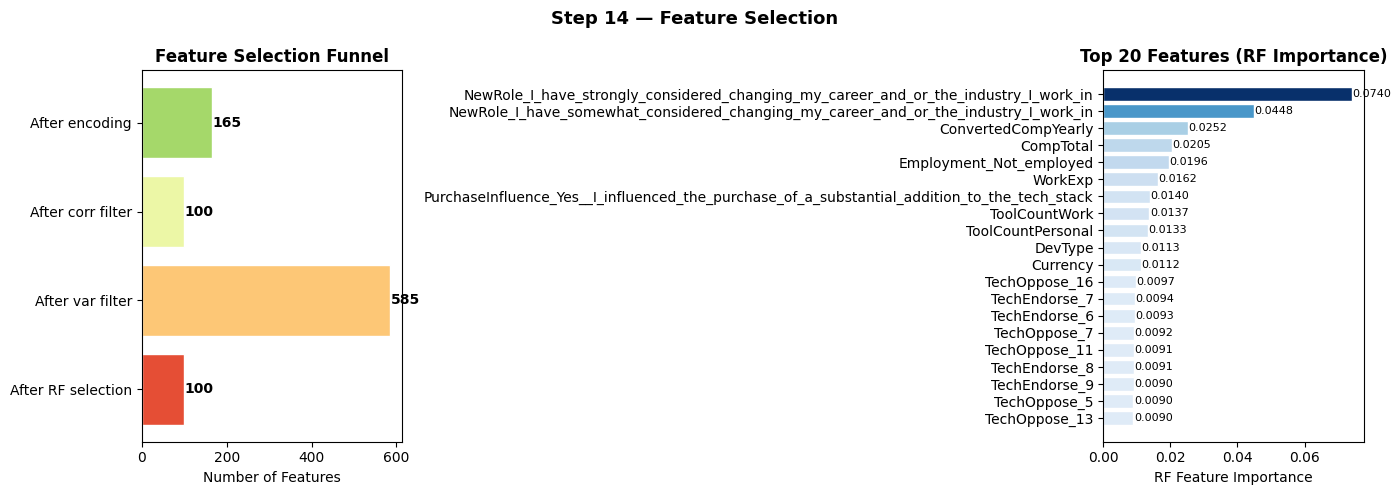

In [41]:
# Funnel
stages = ['After encoding', 'After corr filter', 'After var filter', 'After RF selection']
counts = [
    X_train.shape[1] + len(to_drop_corr),  # approx after encoding
    X_train.shape[1] + len(to_drop_corr) - len(to_drop_corr),
    len(X_before_variance.columns[selector.get_support()]),
    X_train.shape[1]
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = [plt.cm.RdYlGn(v) for v in [0.15, 0.35, 0.55, 0.7, 0.9]]
axes[0].barh(stages[::-1], counts[::-1], color=bar_colors, edgecolor='white')
for i, (s, v) in enumerate(zip(stages[::-1], counts[::-1])):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Number of Features')
axes[0].set_title('Feature Selection Funnel', fontweight='bold')

top20 = importances.head(20)
bar_c = [plt.cm.Blues(v) for v in top20.values / top20.values.max()]
axes[1].barh(top20.index[::-1], top20.values[::-1], color=bar_c[::-1], edgecolor='white')
for i, v in enumerate(top20.values[::-1]):
    axes[1].text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=8)
axes[1].set_xlabel('RF Feature Importance')
axes[1].set_title('Top 20 Features (RF Importance)', fontweight='bold')

plt.suptitle('Step 14 — Feature Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Plot — Top Features Correlation Heatmap

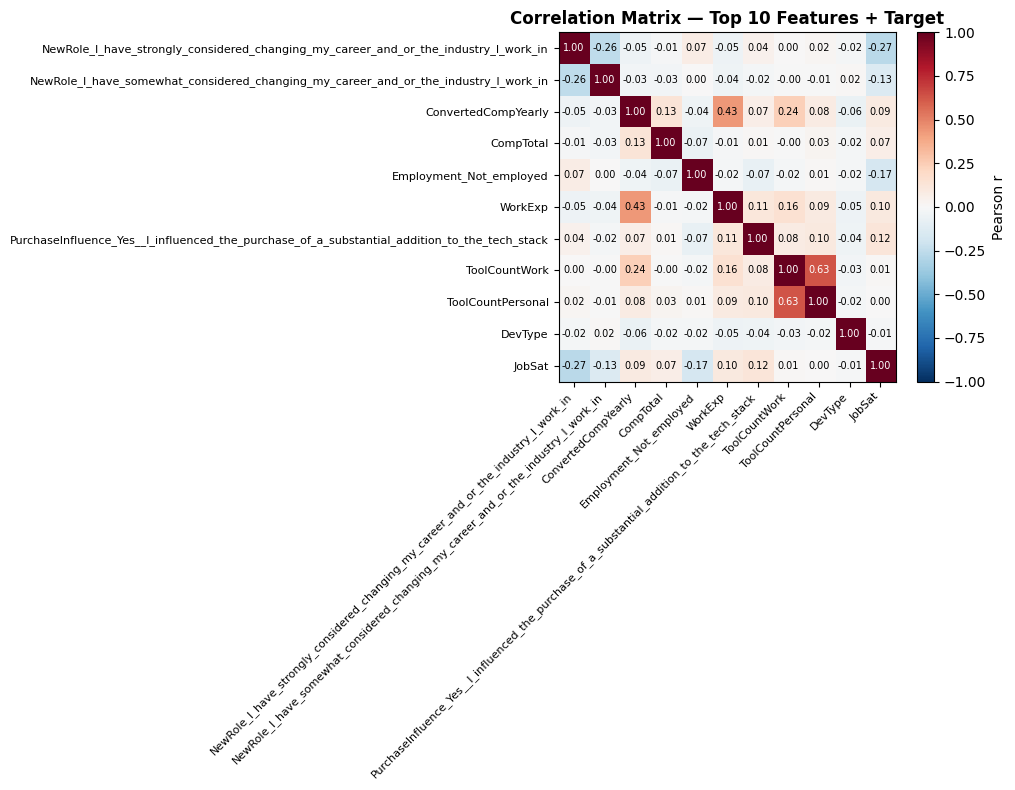

In [42]:
top10 = importances.head(10).index.tolist()
corr_data = X_train[top10].copy()
corr_data['JobSat'] = y_train.values
corr_mat = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(corr_mat.columns)))
ax.set_yticks(range(len(corr_mat.columns)))
ax.set_xticklabels(corr_mat.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_mat.columns, fontsize=8)
for i in range(len(corr_mat)):
    for j in range(len(corr_mat)):
        val = corr_mat.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(val) > 0.5 else 'black')
ax.set_title('Correlation Matrix — Top 10 Features + Target', fontweight='bold')
plt.tight_layout()
plt.show()


## Train & Evaluate Models (without PCA)
We evaluate Linear Regression, Random Forest, Gradient Boosting, HistGradient Boosting, a Voting Regressor ensemble, and an SVC classifier.

In [ ]:
model_results = []

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mse  = mean_squared_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    print(f'\n{name}:')
    print(f'  MSE : {mse:.4f}')
    print(f'  RMSE: {mse**0.5:.4f}')
    print(f'  R²  : {r2:.4f}')
    model_results.append({'Model': name, 'MSE': mse, 'RMSE': mse**0.5, 'R2': r2})
    return model


In [44]:
# Define individual models
lr_model  = LinearRegression()
rf_model  = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5,
                                   min_samples_leaf=2, random_state=42, n_jobs=-1)
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                       max_depth=5, random_state=42)
hgb_model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1,
                                           max_depth=5, random_state=42)

# Voting Regressor ensemble
vr_model = VotingRegressor(estimators=[
    ('lr', lr_model), ('rf', rf_model), ('gbr', gbr_model), ('hgb', hgb_model)
])

models_to_evaluate = [
    ("Linear Regression",       lr_model),
    ("Random Forest",           rf_model),
    ("Gradient Boosting",       gbr_model),
    ("Hist Gradient Boosting",  hgb_model),
    ("Voting Regressor (All)",  vr_model),
]

for name, model in models_to_evaluate:
    evaluate(name, model, X_train, X_test, y_train, y_test)


Linear Regression:
  MSE : 3.1805
  RMSE: 1.7834
  R²  : 0.1907

Random Forest:
  MSE : 3.2112
  RMSE: 1.7920
  R²  : 0.1829

Gradient Boosting:
  MSE : 3.1806
  RMSE: 1.7834
  R²  : 0.1907

Hist Gradient Boosting:
  MSE : 3.1730
  RMSE: 1.7813
  R²  : 0.1926

Voting Regressor (All):
  MSE : 3.1424
  RMSE: 1.7727
  R²  : 0.2004


## Plot — Model Performance Comparison

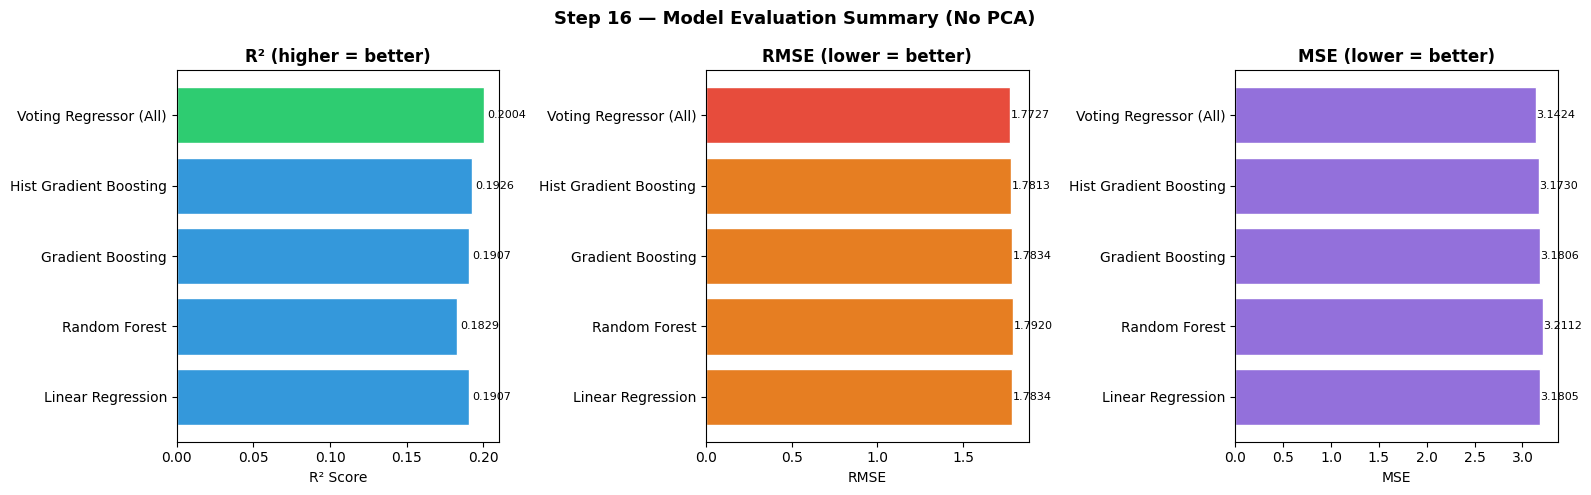

In [45]:
import pandas as pd
res_df = pd.DataFrame(model_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

best_r2 = res_df['R2'].max()
colors_r2 = ['#2ecc71' if v == best_r2 else '#3498db' for v in res_df['R2']]
bars = axes[0].barh(res_df['Model'], res_df['R2'], color=colors_r2, edgecolor='white')
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² (higher = better)', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.7)
for bar, v in zip(bars, res_df['R2']):
    axes[0].text(max(v, 0) + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{v:.4f}', va='center', fontsize=8)

best_rmse = res_df['RMSE'].min()
colors_rmse = ['#e74c3c' if v == best_rmse else '#e67e22' for v in res_df['RMSE']]
bars2 = axes[1].barh(res_df['Model'], res_df['RMSE'], color=colors_rmse, edgecolor='white')
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE (lower = better)', fontweight='bold')
for bar, v in zip(bars2, res_df['RMSE']):
    axes[1].text(v + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{v:.4f}', va='center', fontsize=8)

bars3 = axes[2].barh(res_df['Model'], res_df['MSE'], color='mediumpurple', edgecolor='white')
axes[2].set_xlabel('MSE')
axes[2].set_title('MSE (lower = better)', fontweight='bold')
for bar, v in zip(bars3, res_df['MSE']):
    axes[2].text(v + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Step 16 — Model Evaluation Summary (No PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Plot — Predicted vs Actual & Residuals (HistGradientBoosting)

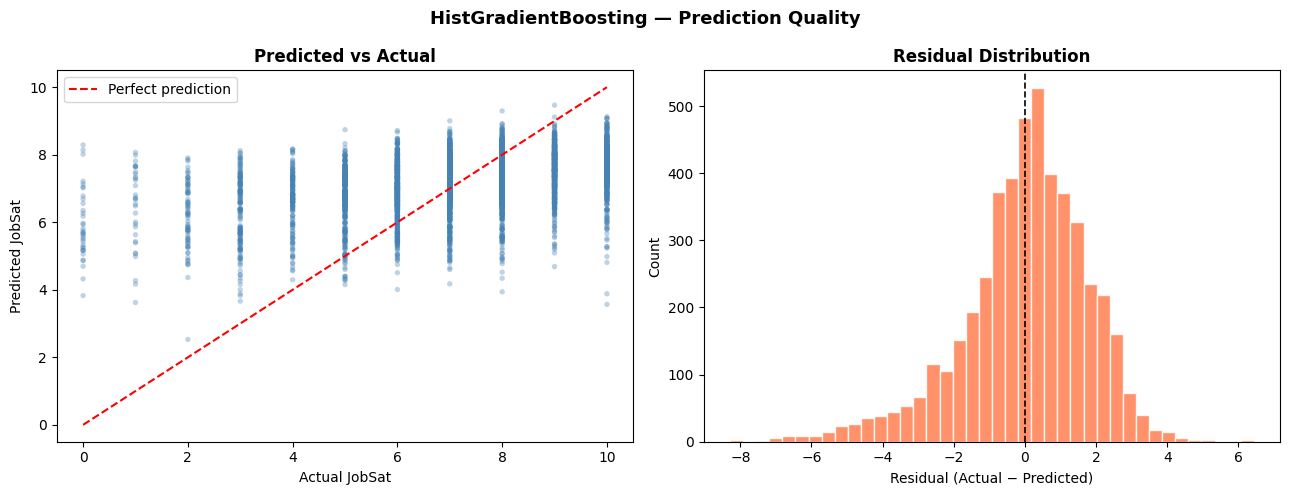

In [46]:
hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_hgb, alpha=0.35, s=15, color='steelblue', edgecolors='none')
mn, mx = float(y_test.min()), float(y_test.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual JobSat')
axes[0].set_ylabel('Predicted JobSat')
axes[0].set_title('Predicted vs Actual', fontweight='bold')
axes[0].legend()

residuals = y_test.values - y_pred_hgb
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('HistGradientBoosting — Prediction Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cross Validation (5-Fold R²)

In [47]:
print('================ CROSS VALIDATION (5-fold R²) ================')

cv_data = {}
for name, model in [
    ('Linear Regression', LinearRegression()),
    ('Random Forest',     RandomForestRegressor(n_estimators=200, max_depth=15,
                          min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100,
                          learning_rate=0.1, max_depth=5, random_state=42)),
]:
    scores = cross_val_score(model, X, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_data[name] = scores
    print(f'\n{name}:')
    print(f'  CV scores : {scores.round(4)}')
    print(f'  Mean R²   : {scores.mean():.4f} ± {scores.std():.4f}')


================ CROSS VALIDATION (5-fold R²) ================

Linear Regression:
  CV scores : [0.2079 0.1894 0.1944 0.191  0.1678]
  Mean R²   : 0.1901 ± 0.0129

Random Forest:
  CV scores : [0.1904 0.173  0.1925 0.1916 0.1545]
  Mean R²   : 0.1804 ± 0.0148

Gradient Boosting:
  CV scores : [0.2067 0.1875 0.1916 0.1981 0.1633]
  Mean R²   : 0.1894 ± 0.0146


## Plot — Cross-Validation R² Distribution

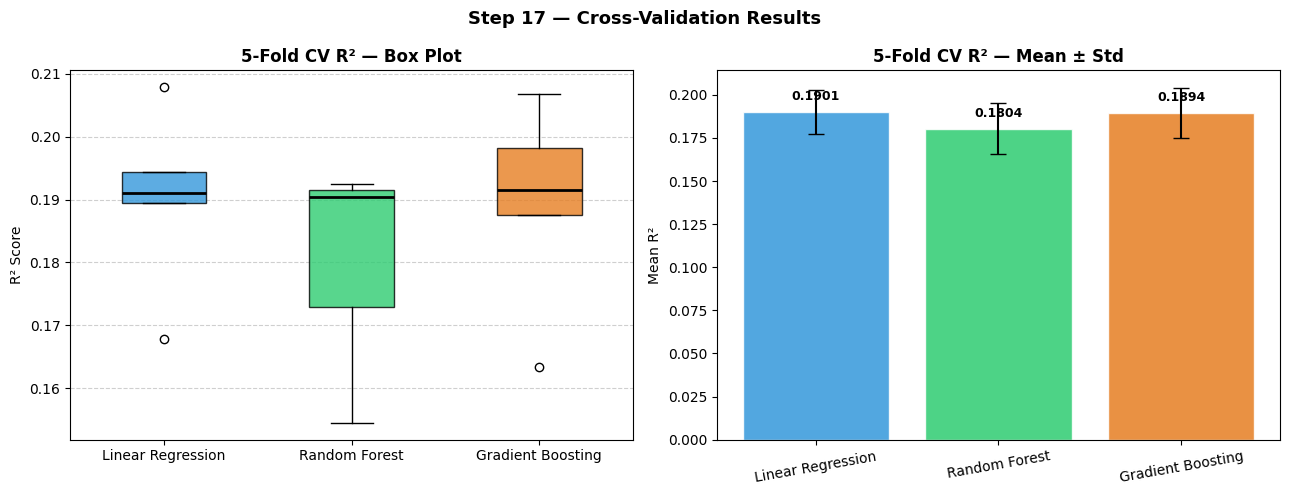

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

positions = list(range(len(cv_data)))
bp = axes[0].boxplot(list(cv_data.values()), positions=positions, patch_artist=True,
                     widths=0.45, medianprops=dict(color='black', linewidth=2))
palette = ['#3498db', '#2ecc71', '#e67e22']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(list(cv_data.keys()), fontsize=10)
axes[0].set_ylabel('R² Score')
axes[0].set_title('5-Fold CV R² — Box Plot', fontweight='bold')
axes[0].yaxis.grid(True, linestyle='--', alpha=0.6)

means = [v.mean() for v in cv_data.values()]
stds  = [v.std()  for v in cv_data.values()]
bars  = axes[1].bar(list(cv_data.keys()), means, yerr=stds, capsize=6,
                    color=palette, edgecolor='white', alpha=0.85)
axes[1].set_ylabel('Mean R²')
axes[1].set_title('5-Fold CV R² — Mean ± Std', fontweight='bold')
for bar, m in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{m:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].tick_params(axis='x', labelrotation=10)

plt.suptitle('Step 17 — Cross-Validation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## PCA Pipeline (Second Modeling Approach)
Scale → PCA (95% variance retained) → refit regression and classification models.

In [49]:
print("================ PCA PIPELINE ================")

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca   = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Original: {X.shape}  →  PCA: {X_pca.shape}")

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pca, y_train, test_size=0.2, random_state=42
)

================ PCA PIPELINE ================
Original: (19168, 100)  →  PCA: (19168, 85)


## Plot — PCA Explained Variance

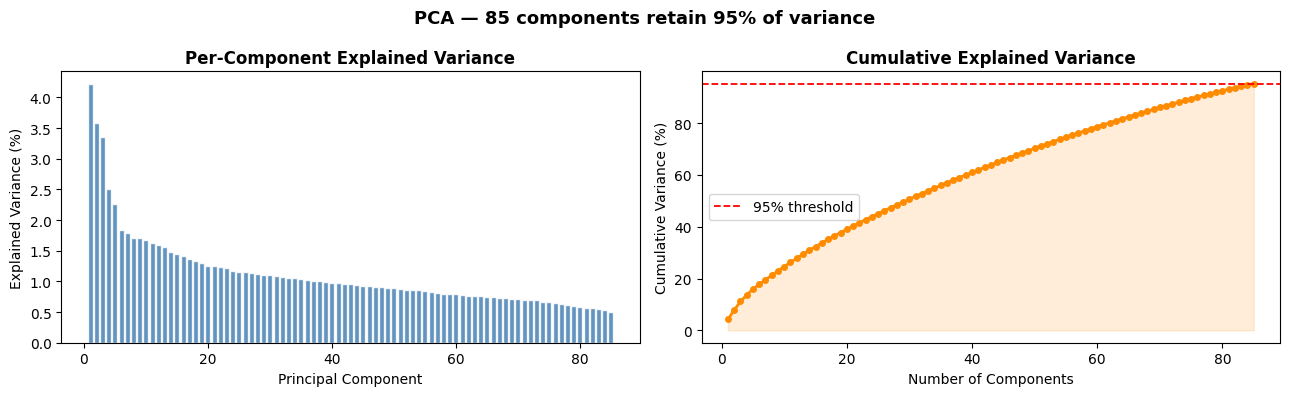

In [50]:
ev    = pca.explained_variance_ratio_
cumev = ev.cumsum()
n_comp = len(ev)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, n_comp + 1), ev * 100, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Per-Component Explained Variance', fontweight='bold')

axes[1].plot(range(1, n_comp + 1), cumev * 100,
             marker='o', markersize=4, color='darkorange', linewidth=2)
axes[1].fill_between(range(1, n_comp + 1), cumev * 100, alpha=0.15, color='darkorange')
axes[1].axhline(95, color='red', linestyle='--', linewidth=1.3, label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.suptitle(f'PCA — {n_comp} components retain 95% of variance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [51]:
pca_results = []

def evaluate_pca(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mse  = mean_squared_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    print(f'\n{name}:')
    print(f'  MSE : {mse:.4f}')
    print(f'  RMSE: {mse**0.5:.4f}')
    print(f'  R²  : {r2:.4f}')
    pca_results.append({'Model': name, 'MSE': mse, 'RMSE': mse**0.5, 'R2': r2})
    return model

for name, model in [
    ('PCA + Linear Regression', LinearRegression()),
    ('PCA + Random Forest',     RandomForestRegressor(n_estimators=200, max_depth=15,
                                min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('PCA + Gradient Boosting', GradientBoostingRegressor(n_estimators=100,
                                learning_rate=0.1, max_depth=5, random_state=42)),
]:
    evaluate_pca(name, model, X_train_p, X_test_p, y_train_p, y_test_p)



PCA + Linear Regression:
  MSE : 3.2129
  RMSE: 1.7925
  R²  : 0.1851

PCA + Random Forest:
  MSE : 3.4226
  RMSE: 1.8500
  R²  : 0.1319

PCA + Gradient Boosting:
  MSE : 3.3580
  RMSE: 1.8325
  R²  : 0.1483


## Plot — PCA vs No-PCA Model Comparison

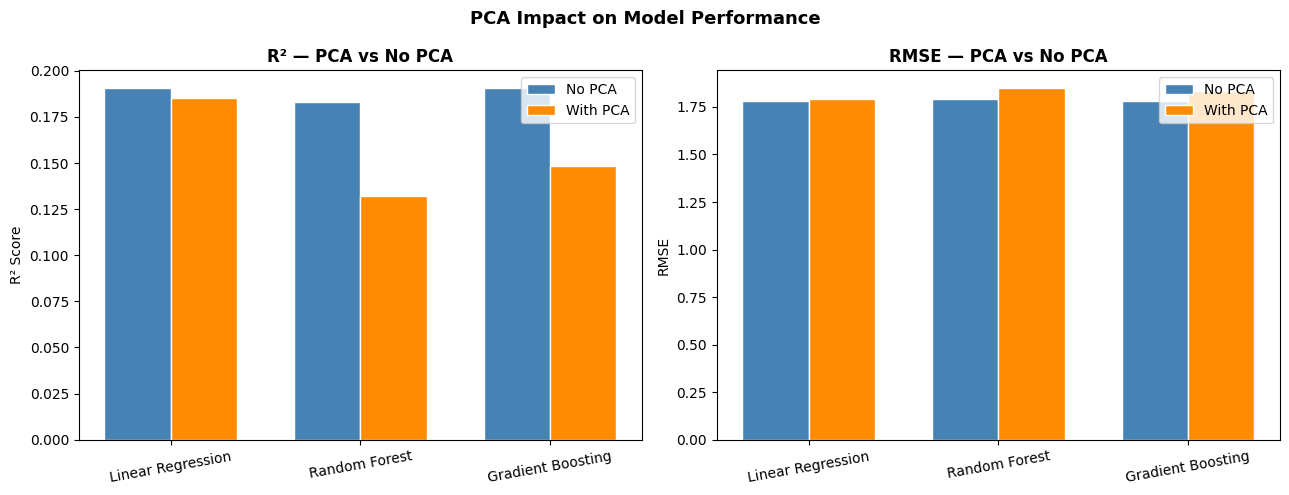

In [52]:
import pandas as pd

common = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
no_pca_df = pd.DataFrame(model_results)
pca_df    = pd.DataFrame(pca_results)

r2_no_pca   = [no_pca_df.loc[no_pca_df['Model'] == m, 'R2'].values[0]   for m in common]
r2_pca      = [pca_df.loc[pca_df['Model'] == f'PCA + {m}', 'R2'].values[0] for m in common]
rmse_no_pca = [no_pca_df.loc[no_pca_df['Model'] == m, 'RMSE'].values[0] for m in common]
rmse_pca    = [pca_df.loc[pca_df['Model'] == f'PCA + {m}', 'RMSE'].values[0] for m in common]

x = list(range(len(common)))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar([i - w/2 for i in x], r2_no_pca, width=w, label='No PCA',
            color='steelblue', edgecolor='white')
axes[0].bar([i + w/2 for i in x], r2_pca,    width=w, label='With PCA',
            color='darkorange', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(common, rotation=10)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² — PCA vs No PCA', fontweight='bold')
axes[0].legend()

axes[1].bar([i - w/2 for i in x], rmse_no_pca, width=w, label='No PCA',
            color='steelblue', edgecolor='white')
axes[1].bar([i + w/2 for i in x], rmse_pca,    width=w, label='With PCA',
            color='darkorange', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(common, rotation=10)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE — PCA vs No PCA', fontweight='bold')
axes[1].legend()

plt.suptitle('PCA Impact on Model Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
import os
import pickle

os.makedirs("saved_pipeline_M1", exist_ok=True)

# ════════════════════════════════════════════════════════════════════
# 0. DROPPED COLUMNS (high-null)
# ════════════════════════════════════════════════════════════════════

with open("saved_pipeline_M1/cols_to_drop.pkl", "wb") as f:
    pickle.dump(list(cols_to_drop), f)

# ════════════════════════════════════════════════════════════════════
# 1. IMPUTER
# ════════════════════════════════════════════════════════════════════

with open("saved_pipeline_M1/rf_imputer.pkl", "wb") as f:
    pickle.dump(rf_imputer, f)

with open("saved_pipeline_M1/numerical_cols.pkl", "wb") as f:
    pickle.dump(list(numerical_cols), f)

with open("saved_pipeline_M1/numeric_cols.pkl", "wb") as f:
    pickle.dump(list(numeric_cols), f)

# ════════════════════════════════════════════════════════════════════
# 2. OUTLIER + LOG TRANSFORM ARTIFACTS
# ════════════════════════════════════════════════════════════════════

with open("saved_pipeline_M1/iqr_bounds.pkl", "wb") as f:
    pickle.dump(iqr_bounds, f)

with open("saved_pipeline_M1/skewed_cols.pkl", "wb") as f:
    pickle.dump(skewed_cols, f)

# ════════════════════════════════════════════════════════════════════
# 3. ENCODING ARTIFACTS
# ════════════════════════════════════════════════════════════════════

with open("saved_pipeline_M1/binary_map.pkl", "wb") as f:
    pickle.dump(binary_map, f)

with open("saved_pipeline_M1/ohe_columns.pkl", "wb") as f:
    pickle.dump(ohe_columns_sanitized, f)

with open("saved_pipeline_M1/freq_maps.pkl", "wb") as f:
    pickle.dump(freq_maps, f)

# Note: Milestone 1 uses `mlb_dict` (returned as 3rd value from encode_multi_value_columns)
with open("saved_pipeline_M1/mlb_encoders.pkl", "wb") as f:
    pickle.dump(mlb_dict, f)

# ════════════════════════════════════════════════════════════════════
# 4. FEATURE SELECTION ARTIFACTS
# ════════════════════════════════════════════════════════════════════

with open("saved_pipeline_M1/corr_drop_cols.pkl", "wb") as f:
    pickle.dump(list(to_drop_corr), f)

with open("saved_pipeline_M1/variance_selector.pkl", "wb") as f:
    pickle.dump(selector, f)

with open("saved_pipeline_M1/selector_input_cols.pkl", "wb") as f:
    pickle.dump(list(X_before_variance.columns), f)

with open("saved_pipeline_M1/top_features.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)

# ════════════════════════════════════════════════════════════════════
# 5. TRAINED MODELS
# ════════════════════════════════════════════════════════════════════

models_to_save = {
    "linear_regression":      lr_model,
    "random_forest":          rf_model,
    "gradient_boosting":      gbr_model,
    "hist_gradient_boosting": hgb_model,
    "voting_regressor":       vr_model,
}

for model_name, model_obj in models_to_save.items():
    with open(f"saved_pipeline_M1/{model_name}.pkl", "wb") as f:
        pickle.dump(model_obj, f)
    print(f"Saved: {model_name}.pkl")

# ════════════════════════════════════════════════════════════════════
# DONE
# ════════════════════════════════════════════════════════════════════

print("\n✅ All artifacts saved to 'saved_pipeline_M1/' folder.")
print("\nFiles saved:")
for fname in sorted(os.listdir("saved_pipeline_M1")):
    print(f"  • {fname}")

Saved: linear_regression.pkl
Saved: random_forest.pkl
Saved: gradient_boosting.pkl
Saved: hist_gradient_boosting.pkl
Saved: voting_regressor.pkl

✅ All artifacts saved to 'saved_pipeline_M1/' folder.

Files saved:
  • binary_map.pkl
  • cols_to_drop.pkl
  • corr_drop_cols.pkl
  • freq_maps.pkl
  • gradient_boosting.pkl
  • hist_gradient_boosting.pkl
  • iqr_bounds.pkl
  • linear_regression.pkl
  • mlb_encoders.pkl
  • numeric_cols.pkl
  • numerical_cols.pkl
  • ohe_columns.pkl
  • random_forest.pkl
  • rf_imputer.pkl
  • selector_input_cols.pkl
  • skewed_cols.pkl
  • top_features.pkl
  • variance_selector.pkl
  • voting_regressor.pkl


: 